In [1]:
#АПАЙ ЕСЛИ ВЫ ЭТО ЧИТАЕТЕ У МЕНЯ ПРОБЛЕМЫ С ЗУГРУЗКОЙ БИБЛИОТЕК ПРОВЕРЯЛ В ДЖУПАЙТЕР ТАМ ВСЕ ОТЛИЧНО РАБОТАТЕТ,  СПАСИБО БОЛЬШОЕ!!!!!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
#1
df = pd.read_excel("catalog_products.xlsx")

print("Форма DataFrame:", df.shape)
print("\nТипы данных:\n", df.dtypes)
print("\nПропуски:\n", df.isnull().sum())
print("\nПервые 5 строк:\n", df.head())

Форма DataFrame: (10000, 50)

Типы данных:
 col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
col_11    int64
col_12    int64
col_13      str
col_14    int64
col_15    int64
col_16      str
col_17    int64
col_18    int64
col_19      str
col_20    int64
col_21    int64
col_22      str
col_23    int64
col_24    int64
col_25      str
col_26    int64
col_27    int64
col_28      str
col_29    int64
col_30    int64
col_31      str
col_32    int64
col_33    int64
col_34      str
col_35    int64
col_36    int64
col_37      str
col_38    int64
col_39    int64
col_40      str
col_41    int64
col_42    int64
col_43      str
col_44    int64
col_45    int64
col_46      str
col_47    int64
col_48    int64
col_49      str
col_50    int64
dtype: object

Пропуски:
 col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_9     0
col_10    0
col_11    

In [28]:
#2
numeric_cols = [f"col_{i}" for i in range(2, 12)]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].mean(), inplace=True)

print("\nПроверка пропусков после обработки:\n", df[numeric_cols].isnull().sum())



Проверка пропусков после обработки:
 col_2         0
col_3         0
col_4     10000
col_5         0
col_6         0
col_7     10000
col_8         0
col_9         0
col_10    10000
col_11        0
dtype: int64


C:\Users\Елдос\AppData\Local\Temp\ipykernel_7916\3323930370.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)


In [29]:
#3
df["total_value"] = df["col_2"] * df["col_3"]
df["double_stock"] = df["col_4"] * 2
df["log_price"] = np.log(df["col_2"])

In [20]:
#4
electronics_expensive = df[
    (df["col_2"] > 500) & (df["col_7"] == "Electronics")
]
print("\nElectronics дорогие:\n", electronics_expensive.head())



Electronics дорогие:
 Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, total_value, double_stock, log_price]
Index: []

[0 rows x 53 columns]


In [21]:
#5
grouped = df.groupby("col_7").agg(
    mean_price=("col_2", "mean"),
    max_price=("col_2", "max"),
    total_quantity=("col_3", "sum")
).reset_index()

print("\nГруппировка:\n", grouped.head())


Группировка:
 Empty DataFrame
Columns: [col_7, mean_price, max_price, total_quantity]
Index: []


In [22]:
#6
stats = pd.DataFrame({
    "column": numeric_cols,
    "mean": [df[col].mean() for col in numeric_cols],
    "median": [df[col].median() for col in numeric_cols],
    "std": [df[col].std() for col in numeric_cols],
})

print("\nСтатистика:\n", stats)


Статистика:
    column      mean  median         std
0   col_2  503.1608   509.0  289.808030
1   col_3  500.4676   502.5  288.052132
2   col_4       NaN     NaN         NaN
3   col_5  494.9370   493.0  290.634660
4   col_6  500.0842   502.0  287.772049
5   col_7       NaN     NaN         NaN
6   col_8  500.1320   498.0  287.280092
7   col_9  494.8945   488.0  288.756643
8  col_10       NaN     NaN         NaN
9  col_11  499.8112   501.0  287.426535


In [23]:
#7
mean_price = df["col_2"].mean()
std_price = df["col_2"].std()

anomalies = df[df["col_2"] > mean_price + 3 * std_price]
print("\nАномалии:\n", anomalies.head())



Аномалии:
 Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, total_value, double_stock, log_price]
Index: []

[0 rows x 53 columns]


In [24]:
#8
corr_matrix = df[numeric_cols].corr()
print("\nКорреляция:\n", corr_matrix)


Корреляция:
            col_2     col_3  col_4     col_5     col_6  col_7     col_8  \
col_2   1.000000 -0.006128    NaN -0.002368 -0.004579    NaN  0.019838   
col_3  -0.006128  1.000000    NaN  0.020303  0.004545    NaN  0.014136   
col_4        NaN       NaN    NaN       NaN       NaN    NaN       NaN   
col_5  -0.002368  0.020303    NaN  1.000000  0.022725    NaN  0.015310   
col_6  -0.004579  0.004545    NaN  0.022725  1.000000    NaN -0.005012   
col_7        NaN       NaN    NaN       NaN       NaN    NaN       NaN   
col_8   0.019838  0.014136    NaN  0.015310 -0.005012    NaN  1.000000   
col_9  -0.008986  0.004623    NaN  0.013237  0.002743    NaN -0.008199   
col_10       NaN       NaN    NaN       NaN       NaN    NaN       NaN   
col_11 -0.006885  0.002812    NaN -0.000047 -0.019907    NaN  0.002730   

           col_9  col_10    col_11  
col_2  -0.008986     NaN -0.006885  
col_3   0.004623     NaN  0.002812  
col_4        NaN     NaN       NaN  
col_5   0.013237     Na

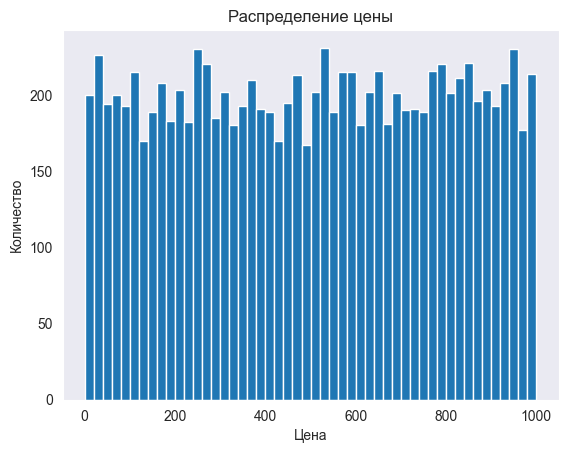

In [25]:
#9
plt.figure()
plt.hist(df["col_2"], bins=50)
plt.title("Распределение цены")
plt.xlabel("Цена")
plt.ylabel("Количество")
plt.grid()
plt.show()

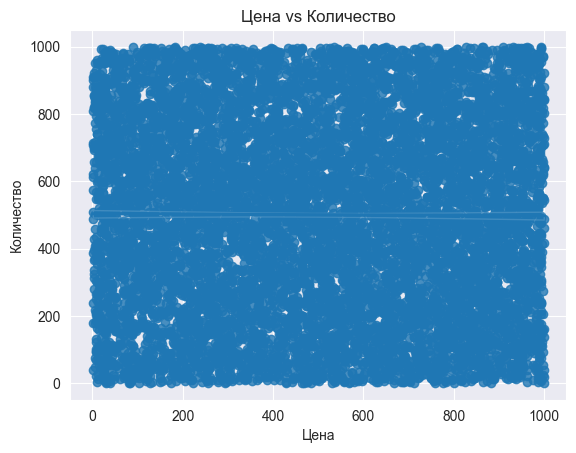

In [26]:
#10
plt.figure()
sns.regplot(x="col_2", y="col_3", data=df)
plt.title("Цена vs Количество")
plt.xlabel("Цена")
plt.ylabel("Количество")
plt.show()


In [1]:
#11
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.boxplot(x="col_7", y="col_2", data=df)
plt.title("Цена по категориям")
plt.xticks(rotation=45)
plt.show()

NameError: name 'df' is not defined

<Figure size 640x480 with 0 Axes>

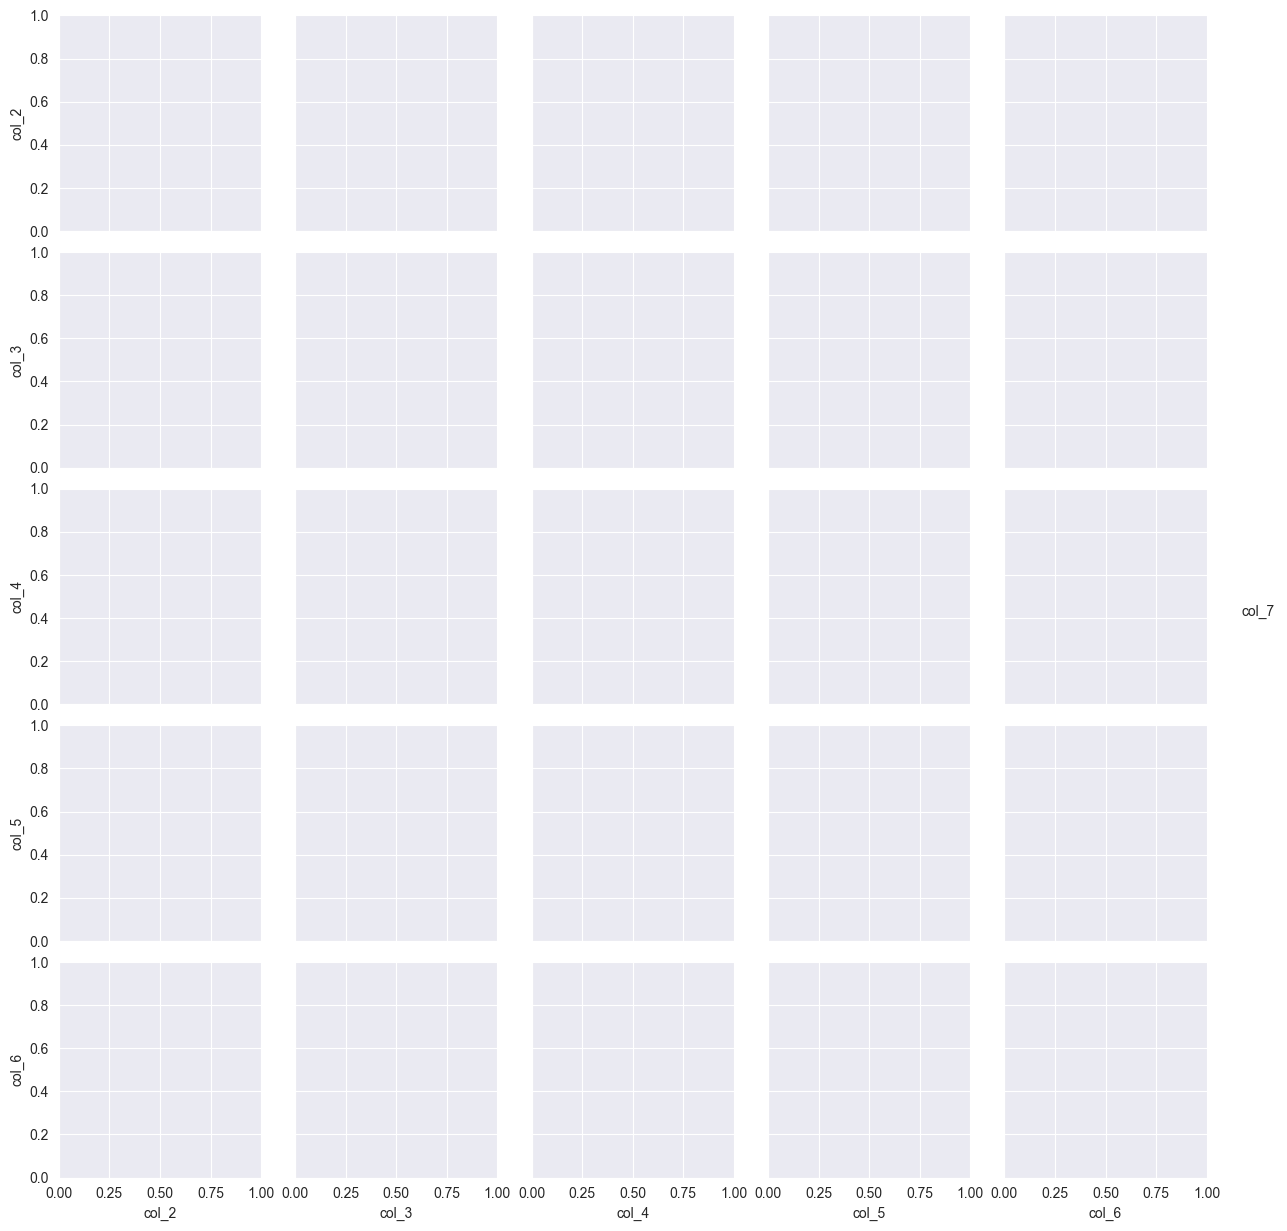

In [30]:
#12
sns.pairplot(df[["col_2","col_3","col_4","col_5","col_6","col_7"]], hue="col_7")
plt.show()


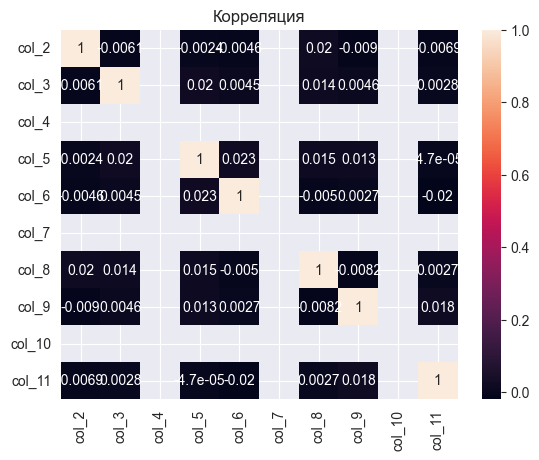

In [31]:
#13
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Корреляция")
plt.show()

In [33]:
#14
df.to_excel("catalog_analysis.xlsx", index=False)

In [34]:
#15
category_summary = df.groupby("col_7").agg(
    count=("col_1", "count"),
    mean_price=("col_2", "mean"),
    total_quantity=("col_3", "sum"),
    mean_log_price=("log_price", "mean")
).reset_index()

print("\nCategory summary:\n", category_summary.head())


Category summary:
 Empty DataFrame
Columns: [col_7, count, mean_price, total_quantity, mean_log_price]
Index: []


In [35]:
#16
idx = df.groupby("col_7")["col_2"].idxmax()
most_expensive = df.loc[idx, ["col_1","col_2","col_7"]]
print("\nСамые дорогие:\n", most_expensive)



Самые дорогие:
 Empty DataFrame
Columns: [col_1, col_2, col_7]
Index: []


In [36]:
#17
top_value = df.sort_values("total_value", ascending=False).head(10)
print("\nТоп по стоимости:\n", top_value)


Топ по стоимости:
             col_1  col_2  col_3  col_4  col_5  col_6  col_7  col_8  col_9  \
3833        Books    994    999    NaN    261    621    NaN    967    623   
4494       Sports    993    997    NaN    649     69    NaN    981    831   
9335     Clothing    994    992    NaN    976      2    NaN    900     28   
6431         Home    988    981    NaN    738    494    NaN    223    878   
3725  Electronics    997    971    NaN    498    424    NaN    497    756   
3389  Electronics    986    979    NaN    167    232    NaN    969    140   
3026  Electronics    997    968    NaN    777    519    NaN    676    414   
9202       Sports    966    996    NaN    178    760    NaN    779    472   
1380  Electronics    963    998    NaN     94    331    NaN    453    748   
3956     Clothing    982    975    NaN     54    108    NaN    694    666   

      col_10  ...  col_45       col_46 col_47  col_48       col_49 col_50  \
3833     NaN  ...     274        Books    280     886  

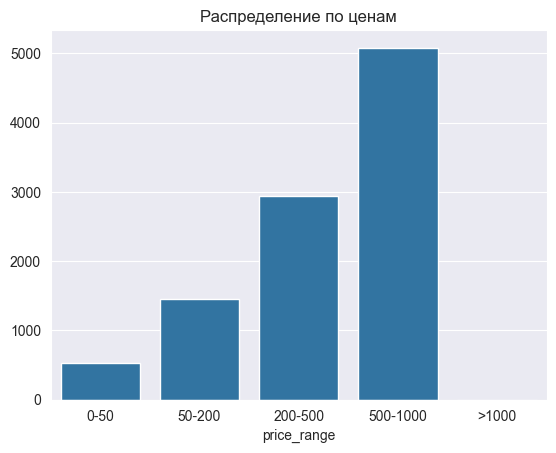

In [37]:
#18
bins = [0,50,200,500,1000,np.inf]
labels = ["0-50","50-200","200-500","500-1000",">1000"]

df["price_range"] = pd.cut(df["col_2"], bins=bins, labels=labels)

price_counts = df["price_range"].value_counts()

plt.figure()
sns.barplot(x=price_counts.index, y=price_counts.values)
plt.title("Распределение по ценам")
plt.show()


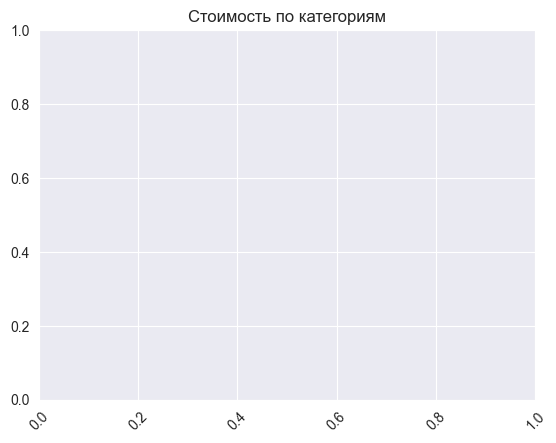

In [38]:
#19
df["stock_value"] = df["col_2"] * df["col_3"]

cat_value = df.groupby("col_7")["stock_value"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=cat_value.index, y=cat_value.values)
plt.xticks(rotation=45)
plt.title("Стоимость по категориям")
plt.show()

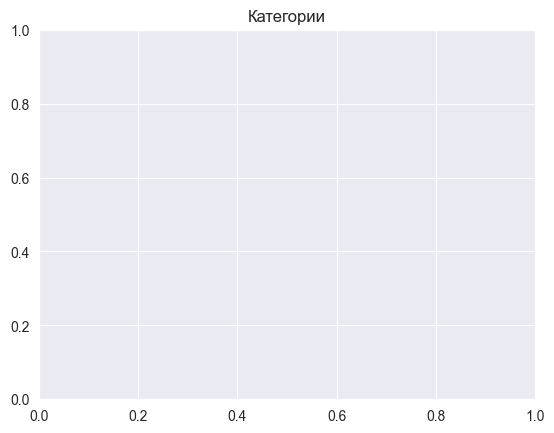

In [39]:
#20
cat_stats = df.groupby("col_7").agg(
    mean_price=("col_2","mean"),
    mean_quantity=("col_3","mean")
).reset_index()

plt.figure()
sns.scatterplot(data=cat_stats, x="mean_price", y="mean_quantity", hue="col_7")
plt.title("Категории")
plt.show()

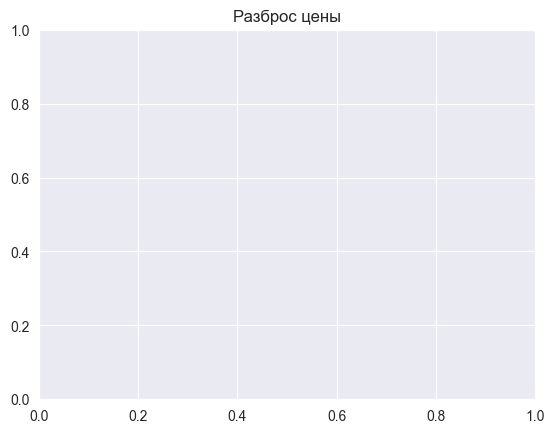

In [40]:
#21
std_price_cat = df.groupby("col_7")["col_2"].std()

plt.figure()
sns.barplot(x=std_price_cat.values, y=std_price_cat.index)
plt.title("Разброс цены")
plt.show()

In [41]:
#22
zero_stock = df[df["col_3"] == 0]
print(zero_stock[["col_1","col_7","col_2"]].head(10))

Empty DataFrame
Columns: [col_1, col_7, col_2]
Index: []


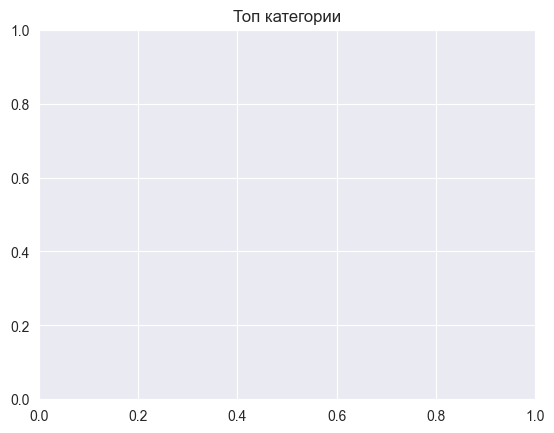

In [43]:
#23
top_cat = df["col_7"].value_counts().head(5)

plt.figure()
sns.barplot(x=top_cat.index, y=top_cat.values)
plt.title("Топ категории")
plt.show()

In [12]:
#24
top_stock = df.sort_values("col_3", ascending=False).head(10)

plt.figure()
sns.barplot(x="col_3", y="col_1", data=top_stock)
plt.title("Топ по запасу")
plt.show()

NameError: name 'df' is not defined

In [ ]:
#25
pivot = pd.pivot_table(df, index="col_7", columns="price_range", values="col_1", aggfunc="count")

plt.figure()
sns.heatmap(pivot, annot=True)
plt.title("Категории vs цены")
plt.show()


In [ ]:
#37
std_price_cat = df.groupby("col_7")["col_2"].std().sort_values(ascending=False)

print("\nСтандартное отклонение цены:\n", std_price_cat)

plt.figure()
sns.barplot(x=std_price_cat.values, y=std_price_cat.index)
plt.title("Разброс цен по категориям")
plt.xlabel("Std цены")
plt.ylabel("Категория")
plt.grid()
plt.show()

In [ ]:
#38
zero_stock = df[df["col_3"] == 0]

print("\nТовары без запаса:\n", zero_stock[["col_1","col_7","col_2"]].head(10))


In [ ]:
#39
top_categories = df["col_7"].value_counts().head(5)

print("\nТоп-5 категорий:\n", top_categories)

plt.figure()
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title("Топ-5 категорий по количеству товаров")
plt.xlabel("Категория")
plt.ylabel("Количество товаров")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
#40
top_stock = df.sort_values("col_3", ascending=False).head(10)

print("\nТоп-10 по запасу:\n", top_stock[["col_1","col_3"]])

plt.figure()
sns.barplot(x="col_3", y="col_1", data=top_stock)
plt.title("Топ-10 товаров по количеству на складе")
plt.xlabel("Количество")
plt.ylabel("Товар")
plt.grid()
plt.show()


In [ ]:
#41
bins = [0, 50, 200, 500, 1000, np.inf]
labels = ["0-50", "50-200", "200-500", "500-1000", ">1000"]

df["price_range"] = pd.cut(df["col_2"], bins=bins, labels=labels)

pivot = pd.pivot_table(
    df,
    index="col_7",
    columns="price_range",
    values="col_1",
    aggfunc="count"
)

print("\nPivot таблица:\n", pivot)

plt.figure()
sns.heatmap(pivot, annot=True)
plt.title("Категории vs диапазоны цен")
plt.xlabel("Диапазон цен")
plt.ylabel("Категория")
plt.show()

In [ ]:
#42
plt.figure()
sns.regplot(x="col_2", y="col_5", data=df)
plt.title("Цена vs Рейтинг")
plt.xlabel("Цена")
plt.ylabel("Рейтинг")
plt.grid()
plt.show()


In [ ]:
#43
sns.pairplot(
    df[["col_2","col_3","col_4","col_5","col_6","col_7"]],
    hue="col_7"
)
plt.show()

In [ ]:
#44
mean_price = df["col_2"].mean()
std_price = df["col_2"].std()

mean_qty = df["col_3"].mean()
std_qty = df["col_3"].std()

extreme_items = df[
    (df["col_2"] > mean_price + 3 * std_price) |
    (df["col_3"] > mean_qty + 3 * std_qty)
]

print("\nАномальные товары:\n", extreme_items.head())


In [ ]:
#45
category_summary = df.groupby("col_7").agg(
    mean_price=("col_2", "mean"),
    total_quantity=("col_3", "sum")
).reset_index()

with pd.ExcelWriter("catalog_final_report.xlsx") as writer:
    df.to_excel(writer, sheet_name="data", index=False)
    category_summary.to_excel(writer, sheet_name="summary", index=False)
    top_stock.to_excel(writer, sheet_name="top_stock", index=False)

print("\nФайл catalog_final_report.xlsx сохранён ✅")